# Surface-ocean CO₂: SOCAT cruises

The [ICOS SOCAT release](https://doi.org/10.18160/BCFM-GNVA) is served at
`https://zarr.icos-cp.eu/icos-socat.zarr` — one group per cruise (expocode
`<PLATFORM><STARTDATE>`), plus a flat `_obs` table that powers the REST API.
QC is **WOCE**: keep flag 2 (`apply_qc=true` does it for you).

First: every ICOS ship track in the Baltic for one month, thinned server-side
with `reduce=track` (Douglas–Peucker per cruise — 39k points become ~2k
without visually changing the tracks).

In [1]:
import io, json, requests
import pandas as pd

url = ("https://zarr.icos-cp.eu/query?id=icos-socat._obs.pCO2"
       "&lat_min=54&lat_max=60&lon_min=10&lon_max=26"
       "&start=2024-06-01&end=2024-07-01"
       "&apply_qc=true&reduce=track&max_rows=100000")
raw = requests.get(url).text
*rows, last = raw.splitlines()
df = pd.read_json(io.StringIO("\n".join(rows)), lines=True)
passport = json.loads(last)["_passport"]
print(f"{len(df):,} track points from "
      f"{df.cruise_idx.nunique()} cruises")

276 track points from 3 cruises


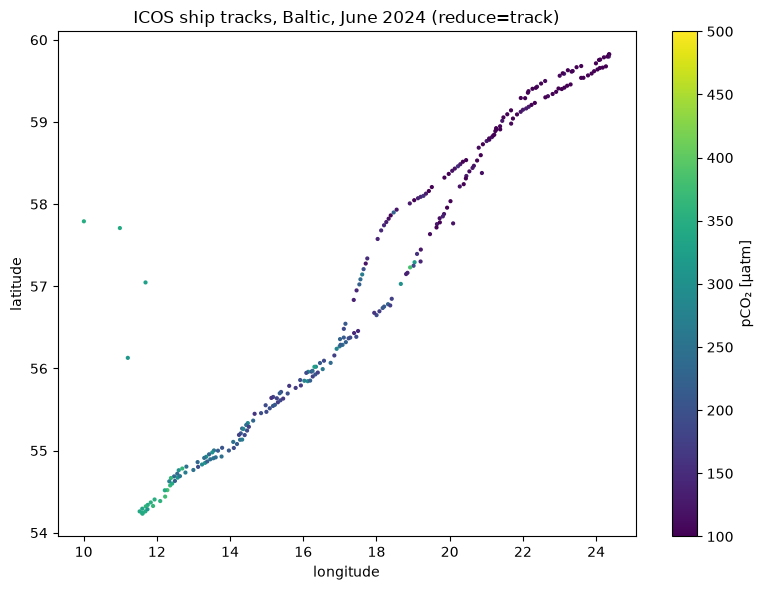

In [2]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(df.longitude, df.latitude, c=df.pCO2, s=4,
                cmap="viridis", vmin=100, vmax=500)
fig.colorbar(sc, label="pCO₂ [µatm]")
ax.set_xlabel("longitude"); ax.set_ylabel("latitude")
ax.set_title("ICOS ship tracks, Baltic, June 2024 (reduce=track)")
fig.tight_layout()

In [3]:
rec = passport["@graph"][1]
print("passport:", rec["totalRows"], "rows, accessed", rec["dateAccessed"])
print("truncated:", rec["truncated"])

passport: 276 rows, accessed 2026-08-17T17:14:38Z
truncated: False


## One cruise in full

For a single crossing, open its group directly — the ship name lives in the
`station_name` attribute, the group name is the expocode:

Finnmaid — 2024-06-24 → 2024-07-31 (38,909 obs)


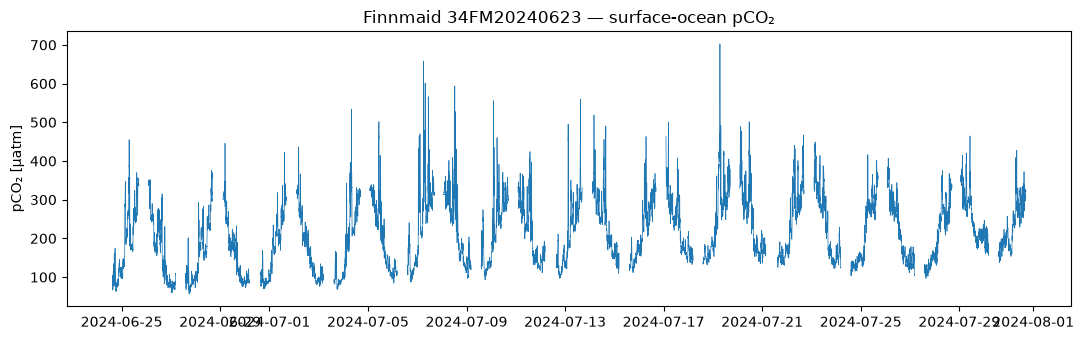

In [4]:
import numpy as np, xarray as xr

cr = xr.open_zarr("https://zarr.icos-cp.eu/icos-socat.zarr/34FM20240623",
                  consolidated=True)
print(cr.attrs["station_name"], "—", cr.attrs["time_start"][:10], "→",
      cr.attrs["time_end"][:10], f"({cr.sizes['time']:,} obs)")
pco2 = cr["pCO2"].where(cr["pCO2_QC"] == 2)          # WOCE: keep flag 2
t = pd.to_datetime(cr.time.values)

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(t, pco2.values, lw=0.5, color="tab:blue")
ax.set_ylabel("pCO₂ [µatm]")
ax.set_title(f"{cr.attrs['station_name']} 34FM20240623 — surface-ocean pCO₂")
fig.tight_layout()

In [5]:
print("citation:", cr.attrs["citation"][:200], "…")
print("licence: ", cr.attrs.get("license", "CC-BY-4.0"))

# and the session passport for these direct reads, on demand:
import requests as rq
r = rq.get("https://zarr.icos-cp.eu/icos-socat.zarr/session/passport").json()
rec = r["passport"]["@graph"][1]
print("session passport:", rec["accessedGroups"], rec["dateAccessed"])

citation: Rehder, G., Bittig, H., Glockzin, M., Neubert, S., Sadkowiak, B., Steinberg, M. (2024). ICOS OTC SOOP Release from Finnmaid, 2024-06-24–2024-07-31, ICOS RI, https://hdl.handle.net/11676/y02f92-mtJz9Jc …
licence:  CC-BY-4.0


session passport: ['34FM20240623', '_obs'] 2026-08-17T17:11:10Z


## Which stations, when?

Ocean "stations" are platforms — SOOP lines and fixed moorings. The flat
`_obs` table indexes every cruise by station (`station_idx`) with its time
span, so one open answers "who measured when" as a Gantt chart:

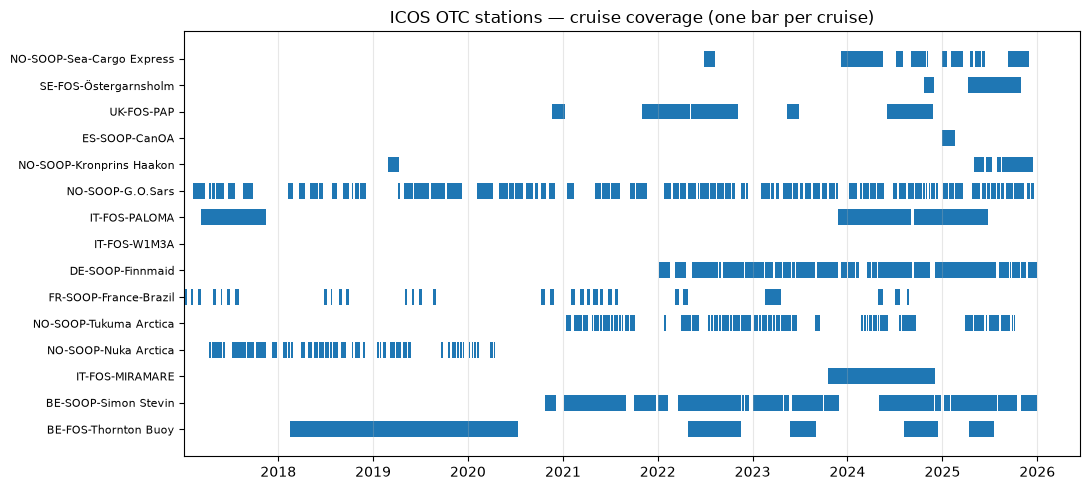

In [6]:
obs = xr.open_zarr("https://zarr.icos-cp.eu/icos-socat.zarr/_obs",
                   consolidated=True)
sids = [str(s) for s in obs["station"].values]
sidx = np.asarray(obs["station_idx"].values)
t0 = pd.to_datetime([str(x) for x in obs["time_start"].values], errors="coerce")
t1 = pd.to_datetime([str(x) for x in obs["time_end"].values], errors="coerce")

fig, ax = plt.subplots(figsize=(11, 5))
for yi, sid in enumerate(sids):
    for ci in np.flatnonzero(sidx == yi):
        if pd.notna(t0[ci]) and pd.notna(t1[ci]):
            ax.barh(yi, t1[ci] - t0[ci], left=t0[ci], height=0.6,
                    color="tab:blue")
ax.set_yticks(range(len(sids)), sids, fontsize=8)
ax.set_title("ICOS OTC stations — cruise coverage (one bar per cruise)")
ax.grid(axis="x", alpha=0.3)
fig.tight_layout()

## One station, one year, on a map

Station ids work directly in the REST route: `station=` selects **all of that
platform's cruises** server-side (`cruise=<expocode>` picks single crossings).
A year of the Nuuk line — Tukuma Arctica, Denmark ↔ Greenland — in one call.
`reduce=stride` decimates each crossing evenly down to the `max_rows` budget
(here ~5% of the year's 71k QC-passed samples), which keeps the pCO₂
structure along the tracks; `reduce=track` is the sparser shape-preserving
wireframe from the Baltic map above:

3,957 evenly-spaced points from 16 crossings in 2024


Text(0.5, 1.0, 'Tukuma Arctica, 2024 — one station= query')

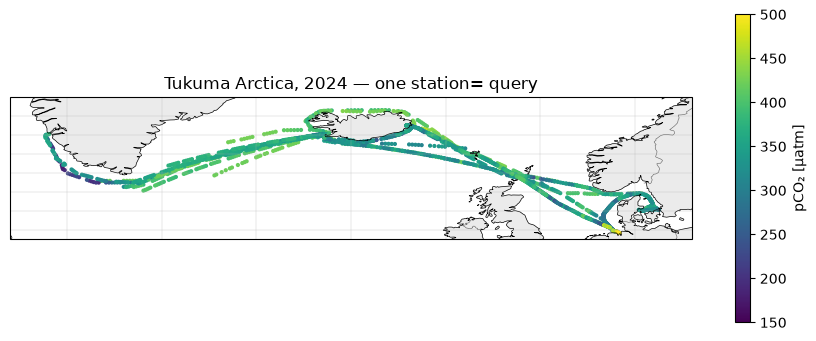

In [7]:
r = requests.get("https://zarr.icos-cp.eu/query", params={
    "id": "icos-socat._obs.pCO2", "station": "NO-SOOP-Tukuma Arctica",
    "start": "2024-01-01", "end": "2025-01-01",
    "apply_qc": "true", "reduce": "stride", "max_rows": 4000})
*rows2, last2 = r.text.splitlines()
tk = pd.read_json(io.StringIO("\n".join(rows2)), lines=True)
print(f"{len(tk):,} evenly-spaced points from "
      f"{tk.cruise_idx.nunique()} crossings in 2024")

import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig = plt.figure(figsize=(11, 5))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([-56, 16, 53, 68], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND.with_scale("50m"), facecolor="0.92")
ax.coastlines(resolution="50m", lw=0.5)
ax.add_feature(cfeature.BORDERS.with_scale("50m"), lw=0.4, alpha=0.6)
sc = ax.scatter(tk.longitude, tk.latitude, c=tk.pCO2, s=4,
                cmap="viridis", vmin=150, vmax=500,
                transform=ccrs.PlateCarree())
fig.colorbar(sc, label="pCO₂ [µatm]", shrink=0.8)
ax.gridlines(draw_labels=False, lw=0.2)
ax.set_title("Tukuma Arctica, 2024 — one station= query")
# (no tight_layout, no gridline labels: both trip cartopy's gridliner on
# GeoAxes — labelled gridlines corrupt the inline backend's tight bbox,
# cropping the saved figure to just the colorbar)

The global SOCAT product (not just ICOS platforms) is the sibling
`socat.zarr` (44M observations, `id=socat._obs.fCO2rec`) and its gridded
form `socat-gridded.zarr` — same recipes (`cruise=` works there too), same
passports.